# [LAB-06] 6. Violin Plot

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
import seaborn as sb

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data("stat_comp_grade")
origin.head()

📚 통계학 전공(STAT) 학생과 전산학 전공(COMP) 학생의 통계학 과목에 대한 중간고사 성적과 기말시험 성적 (출처: 방송통신대학교 통계학개론 수업내용에서 발췌)


,전공,중간고사,기말고사
0,STAT,34,86
1,STAT,50,77
2,STAT,75,74
3,COMP,76,96
4,COMP,61,78


## #02. ViolinPlot 시각화

> 이 단원의 예제는 Boxplot 예제에서 함수 사용하는 메서드 이름만 `boxplot`에서 `violinplot`으로 변경된 형태 입니다.

### 1. 자동 인식 패턴

#### `sb.violinplot()` 함수 사용

- data 파라미터에 `list`, `ndarray`, `Series` 등 모든 연속형 객체를 지정할 수 있다.
- `orient` 파라미터로 방향을 설정한다. (`v` : 세로 (기본값), `h` : 가로)

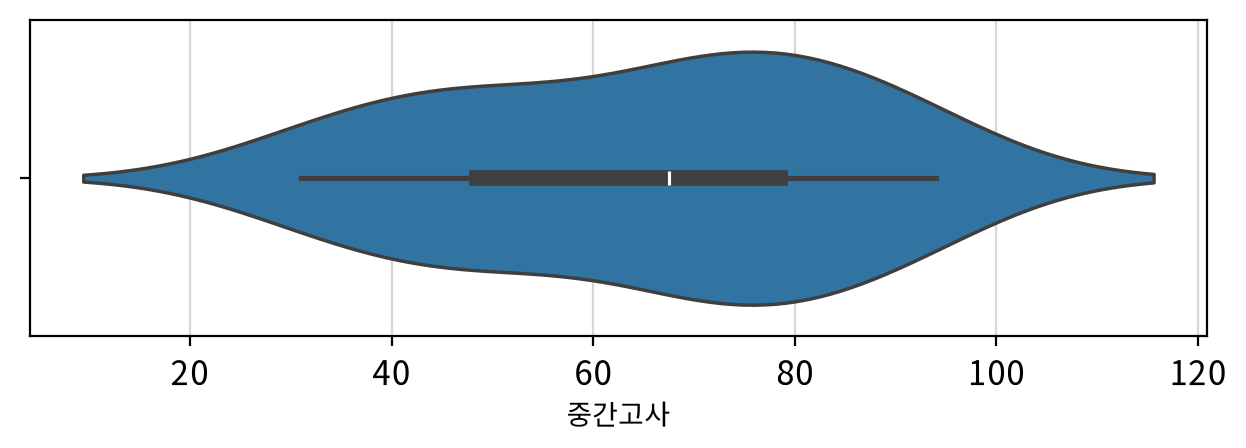

In [3]:
# 그래프 초기화
fig, ax = my_plot.init(width=640, height=240)

# 그래프 그리기
sb.violinplot(data=origin['중간고사'], orient="h")
ax.set_xlabel("중간고사", fontsize=10)

# 출력
my_plot.show()

#### 💡 인사이트

- 🎯 중간고사 점수의 중심(중앙값)은 약 68~70점 부근에 위치함.
- 📦 중간 50% 구간(IQR)은 대략 48~79점 범위로 보임.
- 📈 분포 밀도는 70~80점대에서 가장 두껍게 나타나 해당 구간에 관측치가 많이 모여 있음.
- 📉 10~30점대 저득점 구간은 상대적으로 폭이 얇아 빈도가 낮게 나타남.
- 📏 전체 분포 범위는 대략 10점대부터 110점대 중반까지 퍼져 있음.

### 2. 자동 인식 패턴에 DataFrame 지정을 위한 데이터 전처리

- 바이올린 플롯은 연속형 데이터의 분포를 시각화 하는 그래프이므로, 연속형 데이터만 필터링 한다.

In [4]:
df = origin[['중간고사', '기말고사']]
df.head()

,중간고사,기말고사
0,34,86
1,50,77
2,75,74
3,76,96
4,61,78


### 3. 자동 인식 패턴에 DataFrame 지정

- DataFrame의 모든 컬럼을 한번에 보여 줄 수 있다.

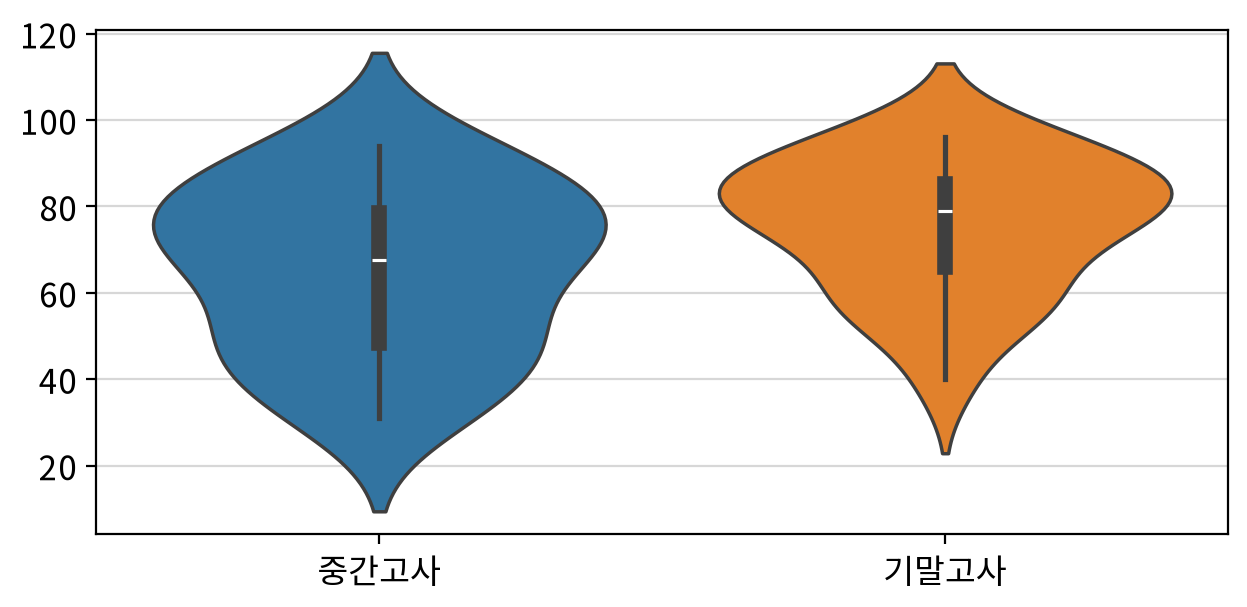

In [5]:
# 그래프 초기화
fig, ax = my_plot.init(width=640, height=320)

# 그래프 그리기
sb.violinplot(data=origin, orient="v")

# 출력
my_plot.show()

#### 💡 인사이트

- 📊 중앙값 비교: 기말고사 중앙값(약 80)이 중간고사 중앙값(약 67)보다 높게 나타남.
- 📦 사분위 구간 비교: 중간고사 IQR은 대략 47~80, 기말고사 IQR은 대략 65~87로 보임.
- 📈 분포 중심: 두 시험 모두 70~85 구간에서 폭이 두꺼워 관측치 밀도가 높은 구간으로 보임.
- 📉 저득점 분포 차이: 중간고사는 30~50 구간 폭이 상대적으로 더 두껍고, 기말고사는 해당 구간이 더 얇게 나타남.
- 📏 범위 비교: 중간고사 하한은 약 30, 기말고사 하한은 약 40으로 보이며 상한은 두 시험 모두 95~97 부근임.

### 4. 개별 데이터 직접 지정 패턴

- **`x` 혹은 `y`중 하나의 파라미터만 지정**
  - `x`에 지정할 경우 가로 그래프가 표시되고, `y`에 지정할 경우 세로 그래프가 표시된다.
  - 가로, 세로 표시 여부에 따라 그래프의 크기를 적절히 설정해야 한다.

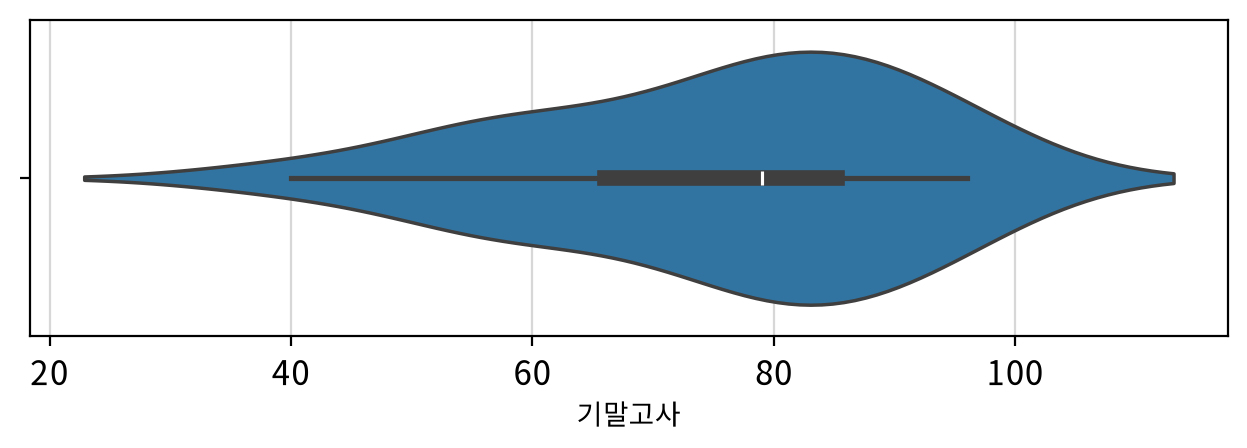

In [6]:
# 그래프 초기화
fig, ax = my_plot.init(width=640, height=240)

# 그래프 그리기
# -> 데이터가 x축으로 전개되므로 가로 방향 그래프가 된다.
sb.violinplot(x=df['기말고사'])
ax.set_xlabel("기말고사", fontsize=10)

# 출력
my_plot.show()

### 5. 데이터 프레임 + 컬럼명 패턴

- **data 파라미터에 데이터 프레임을 지정**
  - x 혹은 y 파라미터에 표시하고자 하는 컬럼명을 지정한다. (동시 사용 불가)
  - 사용하는 파라미터에 따라 그래프의 방향이 결정된다. (x: 가로 방향, y: 세로 방향)

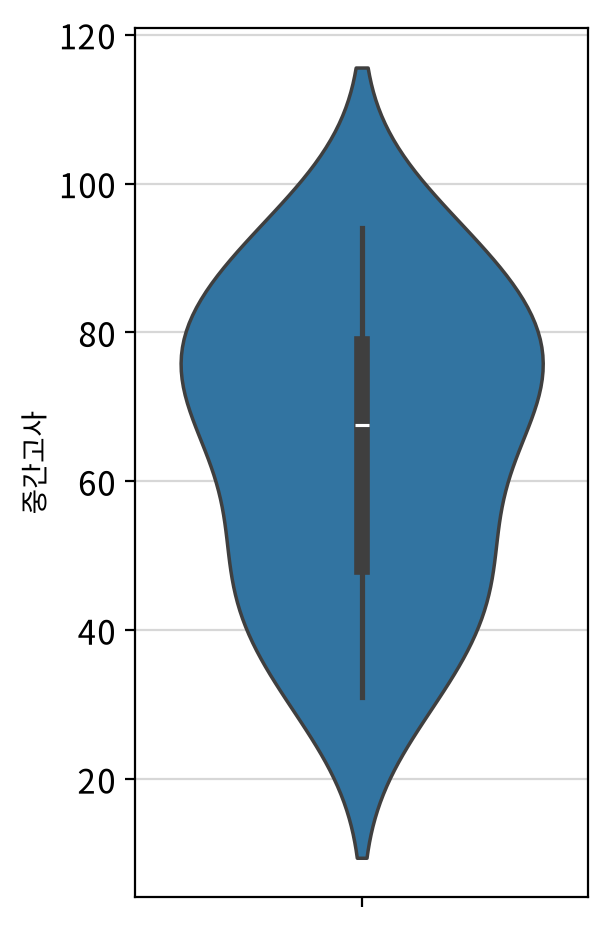

In [7]:
# 그래프 초기화
fig, ax = my_plot.init(width=320, height=480)

# 그래프 그리기
sb.violinplot(data=origin, y='중간고사')
ax.set_ylabel("중간고사", fontsize=10)

# 출력
my_plot.show()

### 6. 범주(hue) 지정

- 하나의 데이터를 범주(명목형 변수)별로 나누어 시각화 한다.
- 여기서는 색상 팔레트를 Set2로 설정함

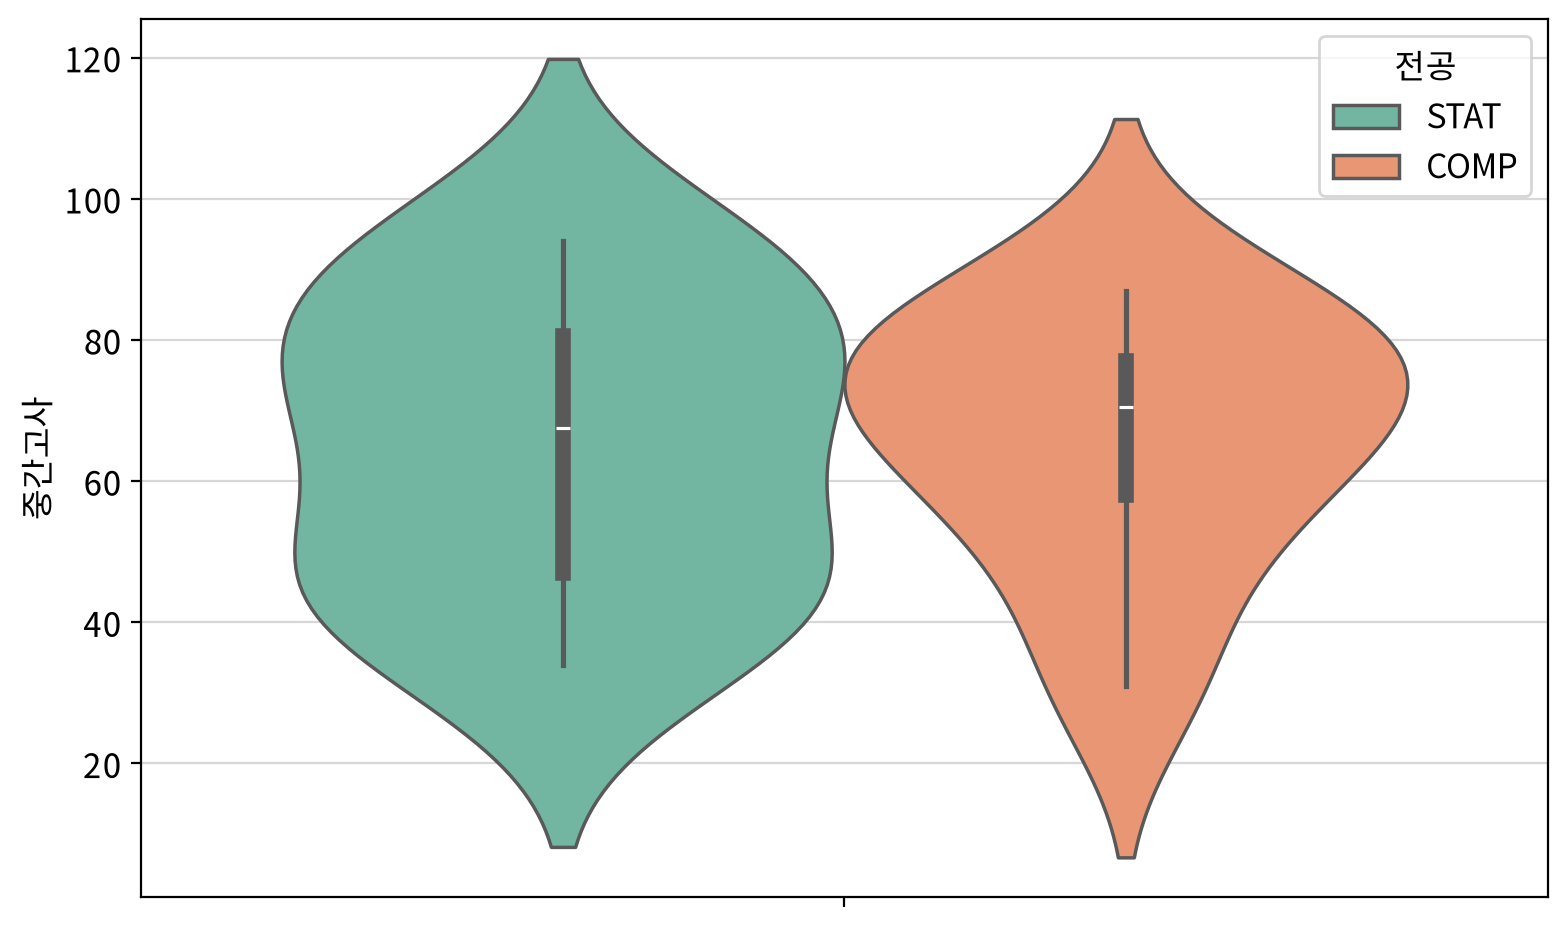

In [8]:
# 그래프 초기화
fig, ax = my_plot.init(width=800, height=480)

# 그래프 그리기
sb.violinplot(data=origin, y='중간고사', hue='전공', palette='Set2')

# 출력
my_plot.show()

#### 💡 인사이트

- 👥 전공별 중앙값 비교에서 COMP가 STAT보다 약간 높게 나타남.  
- 📦 IQR(박스 구간)은 STAT가 더 넓어, 중간 50% 점수 변동 폭이 COMP보다 큼.
- 🌊 바이올린 폭 기준 분포 밀도는 두 전공 모두 70~80점대에서 상대적으로 두껍게 나타남.
- 📉 저점 구간(약 30~50점대)에서는 STAT 쪽 폭이 더 두꺼워, 낮은 점수대 분포가 COMP보다 더 크게 보임.
- 📏 전체 범위는 두 전공 모두 하단은 30점대 초반, 상단은 80~90점대까지 확인됨.

## #03. 모듈화 기능 확인

### 1. 상자그림 모듈화와 사용 방법이 동일하므로 여기서는 대표 사례 하나만 확인

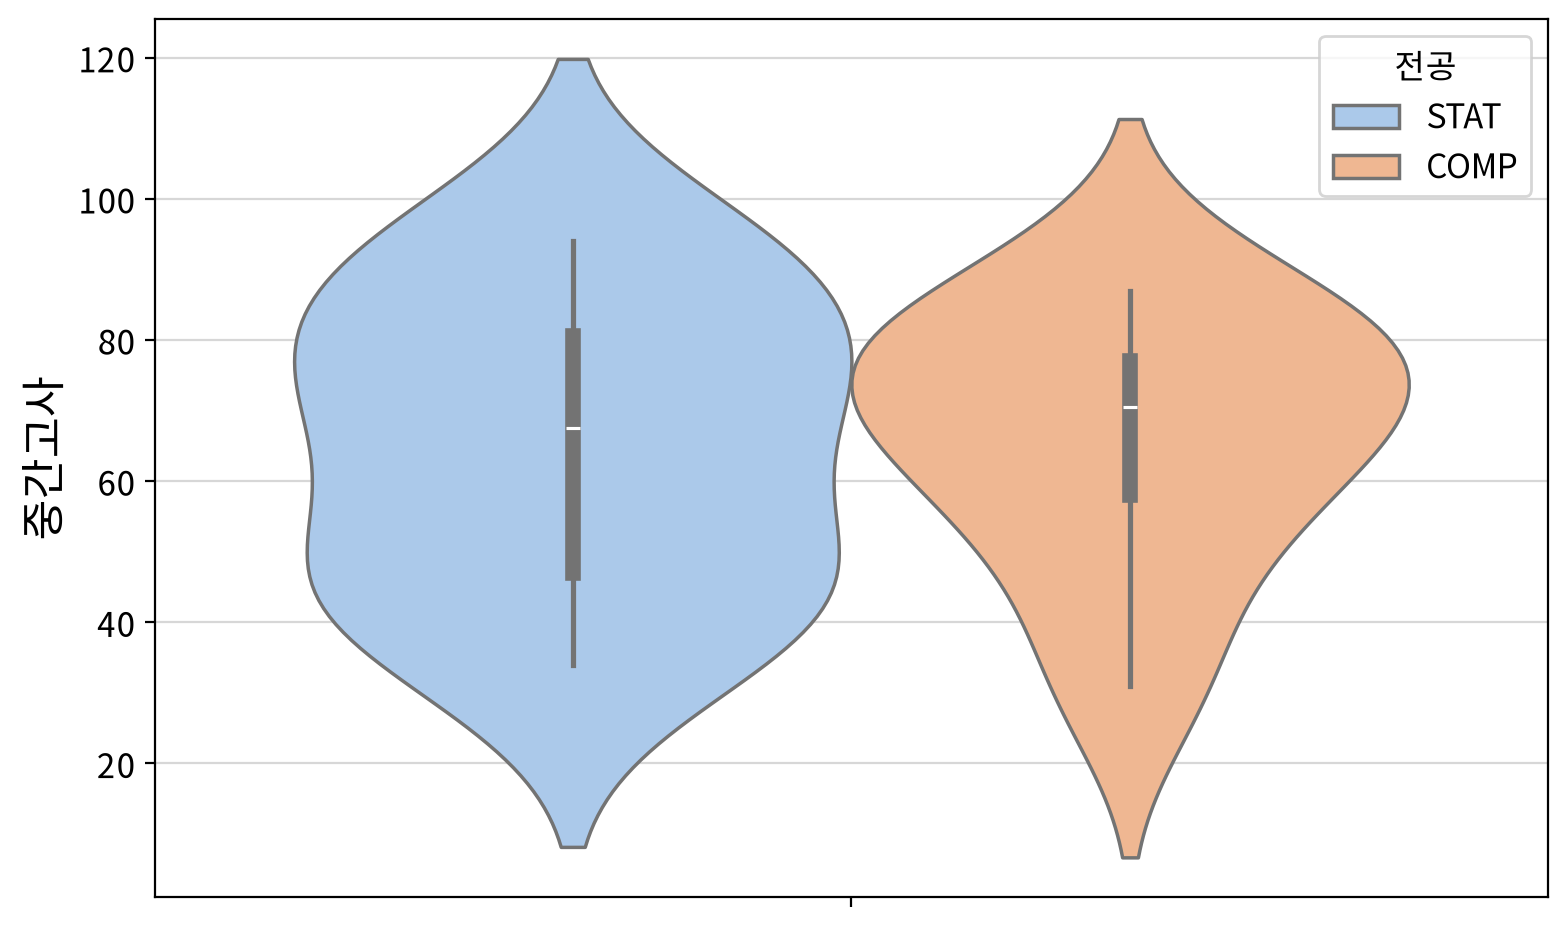

In [9]:
my_plot.violinplot(data=origin, y='중간고사', hue='전공', 
                   ylabel="중간고사",width=800, height=480,
                   palette='pastel')